In [ ]:
PHYLOGWAS_ROOT <- Sys.getenv("PHYLOGWAS_ROOT", unset = "/workdir/sh2246/p_phyloGWAS")
library(data.table)
library(parallel)
library(pheatmap)
library(ape)
library(geiger)
library(asreml)
library(scales)

# data loading

In [ ]:
metadata = read.delim(file.path(PHYLOGWAS_ROOT, "data/Poaceae_metadata_highErrorFiltered_2025.10.08.tsv"),header = T)
rownames(metadata) = metadata$assemblyID

In [ ]:
phyloKMat <- read.table(file.path(PHYLOGWAS_ROOT, "output/phyloK_728Poaceae_astral_20250407.txt"))
phyloKMat = phyloKMat/2 # to correct the error
colnames(phyloKMat) <- rownames(phyloKMat)

In [ ]:
envData = read.table(file.path(PHYLOGWAS_ROOT, "output/envData_707Poaceae_20250804.txt"))

In [ ]:
envDf = cbind(rownames(envData),envData)
colnames(envDf)[1] = "assemblyID"
envDf$assemblyID = as.factor(envDf$assemblyID)

In [ ]:
# load tree
spTre = read.tree(file.path(PHYLOGWAS_ROOT, "output/PoaceaeTree_angiosperm353_astral_filtered_20250407.nwk"))
spTre.rooted = root(spTre,"ASM1935983v1")
spTre.rooted$edge.length[is.na(spTre.rooted$edge.length)] = 0.1

In [ ]:
commonID = Reduce("intersect",list(spTre.rooted$tip.label,rownames(envDf),metadata$assemblyID))
length(commonID)

In [ ]:
spTre.rooted = keep.tip(spTre.rooted,commonID)
spTre.rooted.resolved = ape::multi2di(spTre.rooted) # for permulation

In [36]:
metadata$pacbio = as.factor(grepl("pacbio",metadata$technology,ignore.case = T))
dat = merge(metadata,envDf,by = "assemblyID")
rownames(dat) = dat$assemblyID

# Modeling

In [36]:
myX = read.table(file.path(PHYLOGWAS_ROOT, "output/genomicFeatureData_20251008.txt"),row.names = 1)
myX2 = read.table(file.path(PHYLOGWAS_ROOT, "output/genomicFeatureData_abundant_20251008.txt"),row.names = 1)
myX3 = read.table(file.path(PHYLOGWAS_ROOT, "output/genomicFeatureData_abundantLeaf_20251008.txt"),row.names = 1)
myX4 = read.table(file.path(PHYLOGWAS_ROOT, "output/genomicFeatureData_abundantRoot_20251008.txt"),row.names = 1)
myX5 = read.table(file.path(PHYLOGWAS_ROOT, "output/genomicFeatureData_low_20251008.txt"),row.names = 1)

In [37]:
myX = as.data.frame(myX)
myX2 = as.data.frame(myX2)
myX3 = as.data.frame(myX3)
myX4 = as.data.frame(myX4)
myX5 = as.data.frame(myX5)

In [39]:
scaledDat = apply(myX,2,function(x) (x-mean(x))/sd(x))
scaledDat2 = apply(myX2,2,function(x) (x-mean(x))/sd(x))
scaledDat3 = apply(myX3,2,function(x) (x-mean(x))/sd(x))
scaledDat4 = apply(myX4,2,function(x) (x-mean(x))/sd(x))
scaledDat5 = apply(myX5,2,function(x) (x-mean(x))/sd(x))

In [40]:
dat1= cbind(dat[commonID,],scaledDat)
dat1$assemblyID = as.factor(dat1$assemblyID)

dat2= cbind(dat[commonID,],scaledDat2)
dat2$assemblyID = as.factor(dat1$assemblyID)

dat3= cbind(dat[commonID,],scaledDat3)
dat3$assemblyID = as.factor(dat3$assemblyID)

dat4= cbind(dat[commonID,],scaledDat4)
dat4$assemblyID = as.factor(dat4$assemblyID)

dat5= cbind(dat[commonID,],scaledDat5)
dat5$assemblyID = as.factor(dat5$assemblyID)

### correlation, distribution and variance partioning

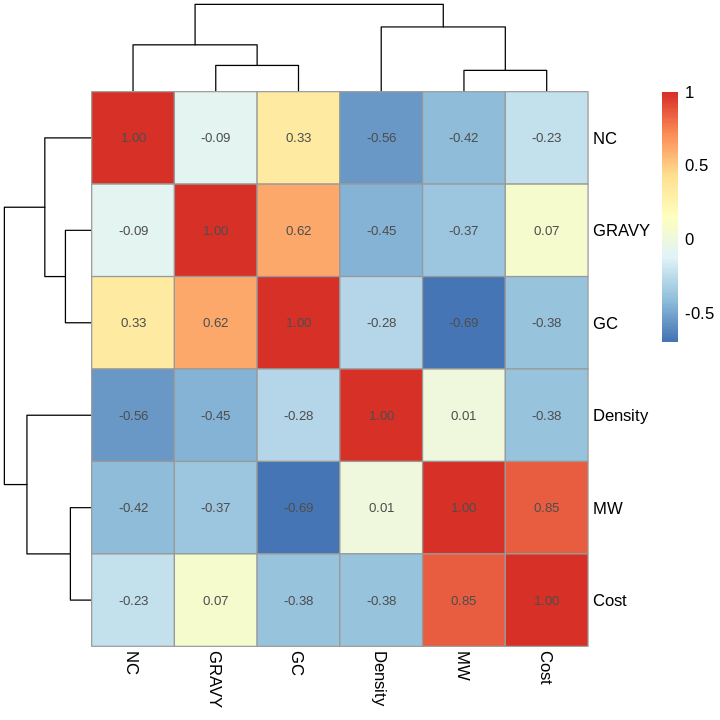

In [42]:
options(repr.plot.width=6, repr.plot.height=6)
pheatmap(cor(dat1[,c("GRAVY","MW","Density","NC","Cost","GC")],
             use = "pairwise.complete.obs",method = "pearson"),
        display_number = T)

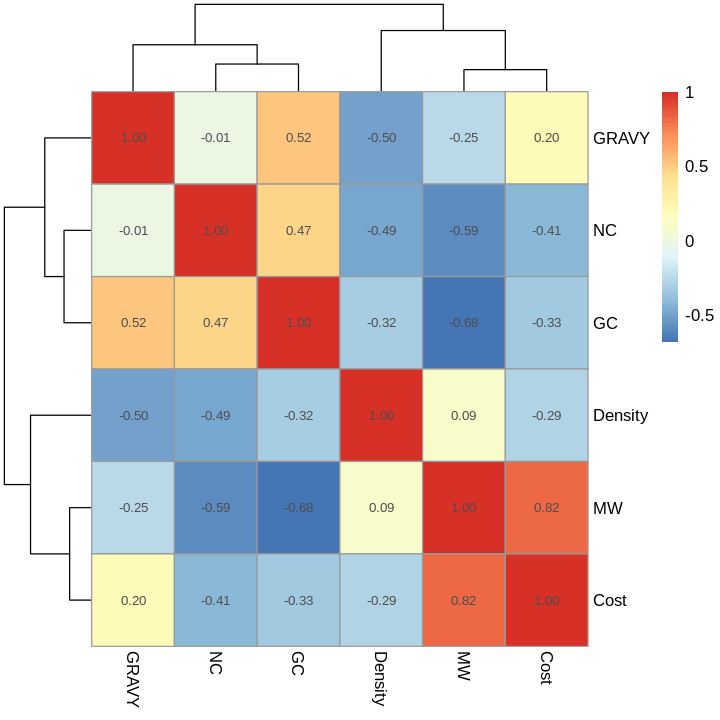

In [43]:
options(repr.plot.width=6, repr.plot.height=6)
pheatmap(cor(dat1[,c("GRAVY","MW","Density","NC","Cost","GC")],
             use = "pairwise.complete.obs",method = "spearman"),
        display_number = T)

In [44]:
phyloKMat_subset = as.matrix(phyloKMat[as.character(dat1$assemblyID),as.character(dat1$assemblyID)])

In [45]:
R2phylo = c()
for (i in c("GRAVY","MW","Density","NC","Cost","GC")){
    myF1 = as.formula(paste0(i, "~ compdup + pacbio"))
    model_Covariate <- asreml(fixed = myF1,random = ~ vm(assemblyID, phyloKMat_subset),
                              ai.sing = F, data = dat1)

    R2phylo = c(R2phylo,summary(model_Covariate)$varcomp$component[1]/sum(summary(model_Covariate)$varcomp$component)) 
}

ASReml Version 4.2 19/05/2026 13:35:19
          LogLik        Sigma2     DF     wall
 1     -191.4316     0.6022604    684   13:35:19
 2     -183.1526     0.5819020    684   13:35:20
 3     -171.8885     0.5504411    684   13:35:20
 4     -161.0605     0.5118905    684   13:35:20
 5     -153.4650     0.4699766    684   13:35:20
 6     -151.3699     0.4447121    684   13:35:20
 7     -151.1458     0.4355329    684   13:35:21
 8     -151.1379     0.4337231    684   13:35:21
 9     -151.1378     0.4334892    684   13:35:21
ASReml Version 4.2 19/05/2026 13:35:21
          LogLik        Sigma2     DF     wall
 1     -245.9650     0.7063736    684   13:35:22
 2     -221.0347     0.6470176    684   13:35:22
 3     -186.4446     0.5651702    684   13:35:22
 4     -154.3608     0.4834644    684   13:35:22
 5     -132.3522     0.4102082    684   13:35:23
 6     -125.1225     0.3663242    684   13:35:23
 7     -123.9519     0.3470299    684   13:35:23
 8     -123.8785     0.3418590    684   13:3

In [46]:
names(R2phylo) = c("GRAVY","MW","Density","NC","Cost","GC")
R2phylo

GRAVY        MW   Density        NC      Cost        GC 
0.7197009 0.8640679 0.8705514 0.8927875 0.8615864 0.9112421

In [51]:
R2phylo_env = c()
for (i in 1:5){
    myF1 = as.formula(paste0("envPC_", i, "~ compdup + pacbio"))
    myF2 = as.formula(paste0("envPC_", i, "~ 1"))
    model_Covariate <- asreml(fixed = myF2,random = ~ vm(assemblyID, phyloKMat),
                              ai.sing = F, data = dat1)
    R2phylo_env = c(R2phylo_env,summary(model_Covariate)$varcomp$component[1]/sum(summary(model_Covariate)$varcomp$component)) 
}

ASReml Version 4.2 19/05/2026 13:42:39
          LogLik        Sigma2     DF     wall
 1     -238.9950     0.7149321    686   13:42:40
 2     -220.3866     0.6691652    686   13:42:40
 3     -193.4664     0.6014559    686   13:42:40
 4     -161.6363     0.5163366    686   13:42:40
 5     -129.0319     0.4171999    686   13:42:41
 6     -111.8483     0.3463036    686   13:42:41
 7     -106.2325     0.3056880    686   13:42:41
 8     -105.0559     0.2865007    686   13:42:42
 9     -104.8953     0.2792098    686   13:42:42
10     -104.8792     0.2768677    686   13:42:42
11     -104.8778     0.2761749    686   13:42:42
ASReml Version 4.2 19/05/2026 13:42:42
          LogLik        Sigma2     DF     wall
 1     -314.3495     0.8905865    686   13:42:43
 2     -300.0914     0.8392963    686   13:42:43
 3     -276.7819     0.7520992    686   13:42:43
 4     -252.9006     0.6519993    686   13:42:44
 5     -235.9902     0.5571172    686   13:42:44
 6     -230.5859     0.5012714    686   13:4

Warning message in asreml(fixed = myF2, random = ~vm(assemblyID, phyloKMat), ai.sing = F, :
“Log-likelihood not converged”


In [52]:
names(R2phylo_env) = paste0("envPC_",1:5)
R2phylo_env

envPC_1   envPC_2   envPC_3   envPC_4   envPC_5 
0.9314520 0.8728032 0.8241605 0.8220590 0.8856935

In [499]:
X_perm = list()
set.seed(123)
for (j in c("GRAVY","MW","Density","NC","Cost","GC")){
    X_perm[[j]] = dat1$assemblyID
    for (i in 1:10){
        # trait vector
        trait_test = dat1[,j]
        names(trait_test) = dat1$assemblyID

        # rate estimates and simulation
        rate_test = ratematrix(spTre.rooted.resolved, trait_test)
        trait_sim = sim.char(spTre.rooted.resolved,rate_test,nsim = 1)
        X_perm[[j]] = data.frame(X_perm[[j]],sort(trait_test)[rank(trait_sim[,,1])])    
    }
#     envPC_perm[[j]] = cbind(rownames(envDf),envPC_perm[[j]])
    colnames(X_perm[[j]]) = c("assemblyID",paste0(j,"_",1:10))
}

In [538]:
R2phylo_perm = c()
for (i in c("GRAVY","MW","Density","NC","Cost","GC")){
    tmpDat = merge(dat1,X_perm[[i]],by = 'assemblyID')
    tmpName = paste0(i,"_",1:10)
    
    tmpR2 = mclapply(tmpName, function(x){
        myF1 = as.formula(paste0(x, "~ compdup + pacbio"))
        model_Covariate <- asreml(fixed = myF1,random = ~ vm(assemblyID, phyloKMat_subset),
                                  ai.sing = F, data = tmpDat)
        return(summary(model_Covariate)$varcomp$component[1]/sum(summary(model_Covariate)$varcomp$component))
    },mc.cores = 10)
    
    R2phylo_perm = cbind(R2phylo_perm,unlist(tmpR2))
}
colnames(R2phylo_perm) = c("GRAVY","MW","Density","NC","Cost","GC")

15      520.3691   0.005239238    684   17:36:00
15      580.3631  0.161053E-05    684   17:36:00  (  1 restrained)
15      441.9587   0.006792617    684   17:36:00
16      580.3041  0.254021E-04    684   17:36:00  (  1 restrained)
17      580.3631  0.161053E-05    684   17:36:00  (  1 restrained)
18      580.3667  0.101875E-06    684   17:36:01
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


In [504]:
R2phylo_perm

GRAVY,MW,Density,NC,Cost,GC
0.9992660,0.9958314,0.9998845,0.9987127,0.9973807,0.9986193
0.9998154,0.9966613,0.9956425,0.9983853,0.9969925,0.9990641
0.9969823,0.9976188,0.9992158,0.9995100,0.9994540,0.9993917
0.9892046,0.9942372,0.9987889,0.9992175,0.9980749,0.9971663
0.9800841,1.0000000,0.9983469,0.9986149,0.9959741,0.9986645
0.9911650,0.9975189,0.9987312,0.9988363,0.9978130,0.9986349
0.9861515,0.9956643,0.9995135,0.9984360,0.9921965,0.9968657
0.9826299,0.9995644,0.9991634,0.9985229,0.9955365,0.9970497
0.9987347,0.9940958,0.9988167,0.9990995,0.9967363,0.9997072
0.9851325,0.9996492,0.9982323,0.9998539,0.9979361,0.9993326


### visualization (Figure 3A and 3B)

In [229]:
# Custom histogram panel (diagonal)
panel.hist <- function(x, ...) {
  usr <- par("usr"); on.exit(par(usr = usr))
  h <- hist(x, plot = FALSE)
  breaks <- h$breaks
  y <- h$counts / sum(h$counts)  # Normalize to probability density
  y <- y / max(y)                # Rescale to [0,1]
  
  par(usr = c(min(breaks), max(breaks), 0, 1.5))
  rect(breaks[-length(breaks)], 0, breaks[-1], y, col = "lightgray", border = NULL)
#     text(median(x),1.25)
}

# Custom correlation panel (upper triangle)
panel.cor <- function(x, y, digits = 2, prefix = "", cex.cor = 1.2, ...) {
  usr <- par("usr"); on.exit(par(usr = usr))
  par(usr = c(0, 1, 0, 1))
  r <- cor(x, y, use = "complete.obs",method = "pearson")
  txt <- formatC(r, format = "f", digits = digits)
  text(0.5, 0.5, paste0(prefix, txt), cex = cex.cor )
}

# Custom heat.scatter panel (lower triangle)
panel.heat <- function(x, y, ...) {
  usr <- par("usr"); on.exit(par(usr = usr))
  par(new = TRUE)
  LSD::heatscatter(x, y, xlab = "", ylab = "", xaxt = "n", yaxt = "n", main = "" )
}


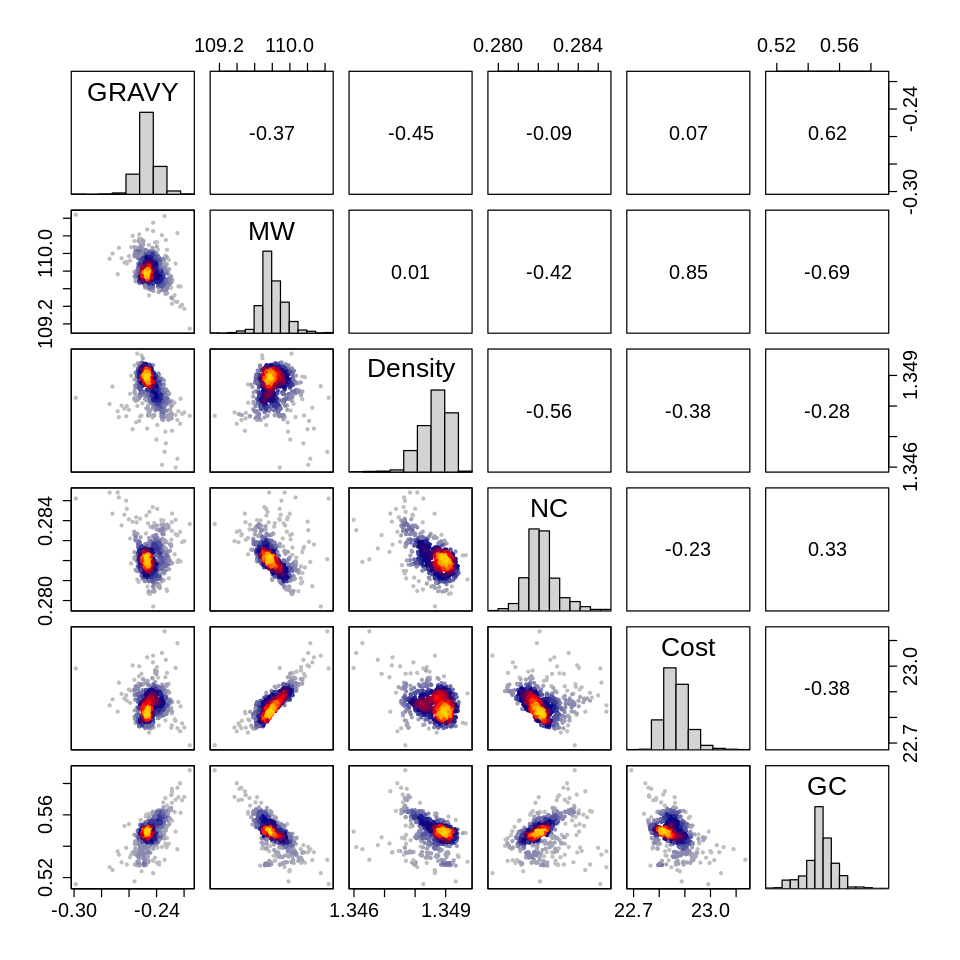

In [232]:
options(repr.plot.width=8, repr.plot.height=8)
pairs(myX,labels = c("GRAVY","MW","Density","NC","Cost","GC"),
      diag.panel = panel.hist,
      lower.panel = panel.heat,
      upper.panel = panel.cor,cex = 1.5,cex.axis = 1.5)

In [505]:
R2phylo_perm_avg = apply(R2phylo_perm,2,mean) 
R2phylo_perm_sd = apply(R2phylo_perm,2,sd) 
R2phylo_perm_avg
R2phylo_perm_sd

GRAVY        MW   Density        NC      Cost        GC 
0.9909166 0.9970841 0.9986336 0.9989189 0.9968095 0.9984496

GRAVY          MW     Density          NC        Cost          GC 
0.007393579 0.002173262 0.001165048 0.000490127 0.001967349 0.001046207

In [ ]:
text(y= bp, x = round(rev(R2phylo),3)*100,labels = round(rev(R2phylo),3)*100,pos = 2)

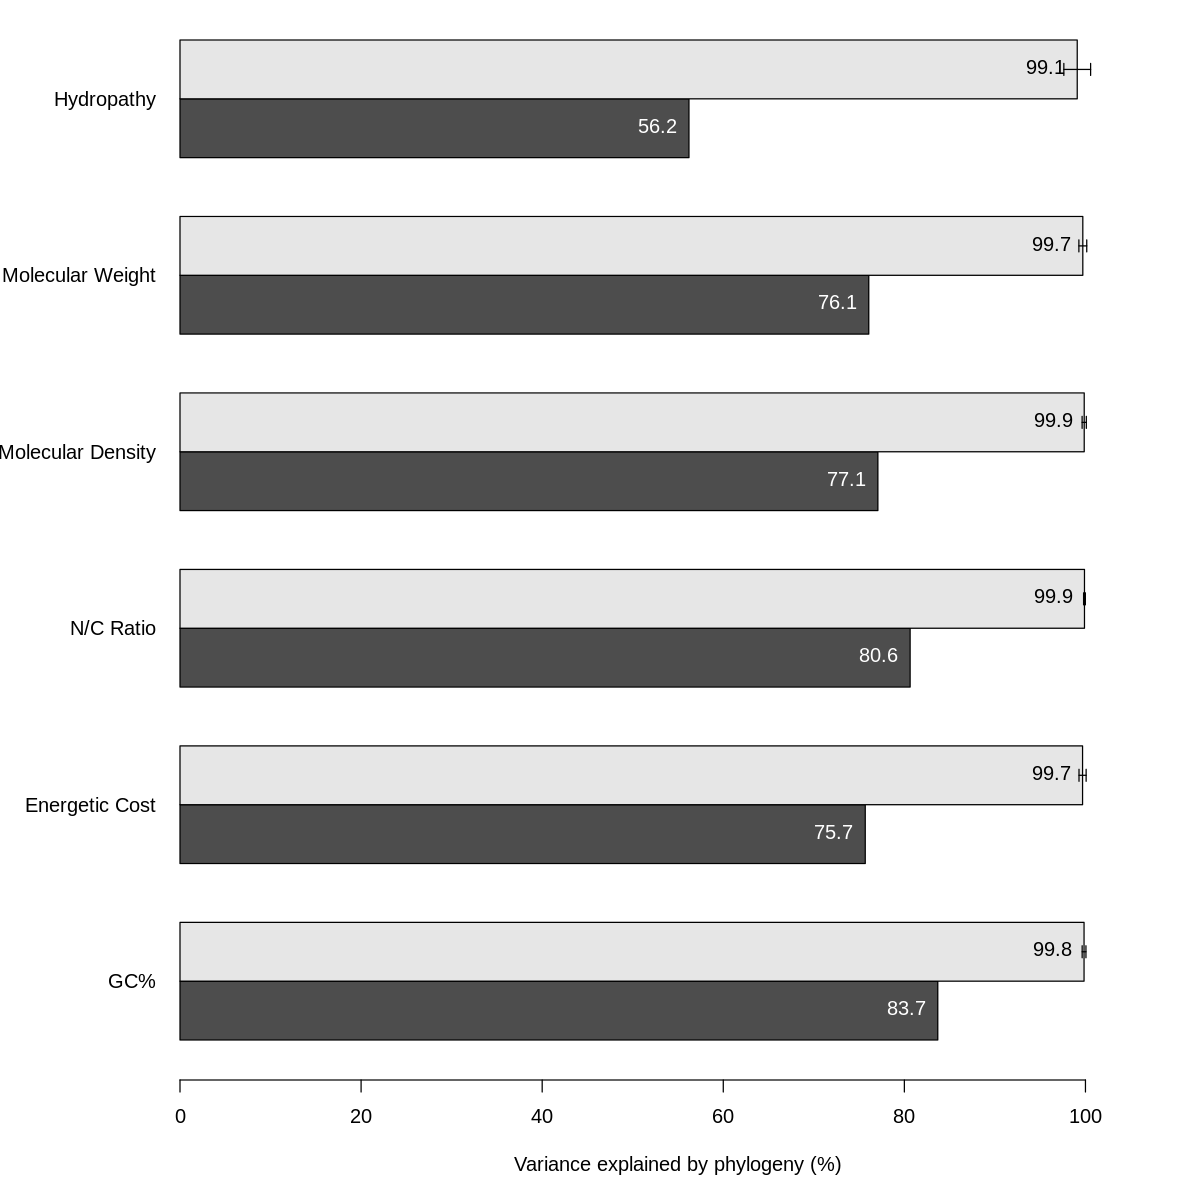

In [509]:
par(mar = c(5,7.5,0,1))
bp=barplot(rbind(rev(R2phylo),rev(R2phylo_perm_avg))*100,horiz = T,las =1,
           main = "",xlim = c(0,110),beside = T,xlab = "Variance explained by phylogeny (%)",
           names.arg = c("GC%", "Energetic Cost","N/C Ratio","Molecular Density", "Molecular Weight",
                         "Hydropathy"))
text(y= bp, x = round(rbind(rev(R2phylo),rev(R2phylo_perm_avg)),3)*100,
     labels = round(rbind(rev(R2phylo),rev(R2phylo_perm_avg)),3)*100,pos = 2,col = c("white","black"))
arrows(x0 = rev(R2phylo_perm_avg)*100-2*rev(R2phylo_perm_sd)*100,
       x1 = rev(R2phylo_perm_avg)*100+2*rev(R2phylo_perm_sd)*100,
       y0 = bp[seq(2,12,2)],y1 = bp[seq(2,12,2)],code = 3, length = .05,angle = 90)

In [56]:
png(file.path(PHYLOGWAS_ROOT, "output/figure/Fig4a_v3.png"),width = 16.6,height = 8.7*.5,units = "cm",
    res = 600,pointsize = 10)
layout(matrix(1:6,nrow = 1),widths = c(1.6,1,1,1,1,1))
for(i in 1:6){
    if(i == 1) {par(mar = c(4,5,3,0.1))
               }else par(mar = c(4,.1,3,.6))
    hist(myX[,i],ylab = ifelse(i ==1, "Frequency",""),breaks = 50,col = "darkblue",border = "darkblue",
         yaxt = ifelse(i!=1,'n','s'),
         main = rev(c("GC%", "Energetic Cost","Nitrogen/Carbon","Density", "Molecular Weight","Hydropathy"))[i],
         xlab = c("","Da per residue",expression(g/cm^3),"","ATP per residue","")[i],
         ylim = c(0,140),las = 1)
    segments(x0 = mean(myX[,i]),x1 = mean(myX[,i])+sd(myX[,i]),y0 = 125, y1 = 125, col = "red",lwd = 2)
    text(x = mean(myX[,i])+sd(myX[,i])/2,y = 125, label = round(sd(myX[,i]),4),pos = 1,col = "red")
    text(x = mean(myX[,i])+sd(myX[,i])/2,y = 125, label = "1 SD",pos = 3,col = "red")
}
dev.off()

pdf 
  2

In [48]:
png(file.path(PHYLOGWAS_ROOT, "output/figure/Fig4b_v4.png"),width = 8.7,height = 8.7,units = "cm",
    res = 600,pointsize = 9.5)
par(mar = c(0,0.5,0,0.5))
bp=barplot(rbind(rev(R2phylo),1-rev(R2phylo))*100,horiz = T,las =1, col = c("lightblue","darkblue"),
           main = "",xlim = c(0,100),beside = F,xlab = "",xaxt = 'n',
           names.arg = NULL)
# text(y= rep(bp, each = 2), x = round(rbind((1-rev(R2phylo))/2,1-rev(R2phylo)+rev(R2phylo)/2),3)*100,
#      labels = paste0(round(rbind(1-rev(R2phylo),rev(R2phylo)),3)*100,"%"),col = c("white","black"),cex = 1.5)
dev.off()

pdf 
  2

### phylogenetic mixed modeling

In [59]:
fit_model <- function(data, Kmat,responseVar,predictor) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    Coeff = c()
    WaldPval = c()
    for (i in predictor){
        fullFM = as.formula(paste0(responseVar, "~", i ,"+ compdup + pacbio"))
        model_full <- asreml(fixed = fullFM,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = data)

        modelWald <- wald.asreml(model_full)
        if(model_full$converge) {
            Coeff <- c(Coeff,model_full$coefficients$fixed[2])
            WaldPval <- c(WaldPval,modelWald[2,4])
        }else {
            Coeff <- c(Coeff,NA)
            WaldPval <- c(WaldPval,NA)
        }
    }
    
    out = c(Coeff,WaldPval)
    names(out) = c(paste("Coeff",predictor,sep = "_"),
                   paste("P",predictor,sep = "_"))
    return(out)
}

In [264]:
testMLM = mclapply(c(paste("envPC",1:10,sep = "_"),"TN1_GSDE_5_quan50","TC1_GSDE_5_quan50","bio08_Mean_Temperature_Wettest_Quarter_quan50"),
                function(x) fit_model(dat1,phyloKMat,x,c("GRAVY","MW","Density","NC","Cost","GC")),mc.cores = 13)

testMLM = t(simplify2array(testMLM))
testMLM = as.data.frame(testMLM)
rownames(testMLM) = c(paste("envPC",1:10,sep = "_"),"TN1_GSDE_5_quan50","TC1_GSDE_5_quan50","bio08_Mean_Temperature_Wettest_Quarter_quan50")

In [265]:
testMLM2 = mclapply(c(paste("envPC",1:10,sep = "_"),"TN1_GSDE_5_quan50","TC1_GSDE_5_quan50","bio08_Mean_Temperature_Wettest_Quarter_quan50"),
                function(x) fit_model(dat2,phyloKMat,x,c("GRAVY","MW","Density","NC","Cost","GC")),mc.cores = 13)

testMLM2 = t(simplify2array(testMLM2))
testMLM2 = as.data.frame(testMLM2)
rownames(testMLM2) = c(paste("envPC",1:10,sep = "_"),"TN1_GSDE_5_quan50","TC1_GSDE_5_quan50","bio08_Mean_Temperature_Wettest_Quarter_quan50")

In [266]:
testMLM3 = mclapply(c(paste("envPC",1:10,sep = "_"),"TN1_GSDE_5_quan50","TC1_GSDE_5_quan50","bio08_Mean_Temperature_Wettest_Quarter_quan50"),
                function(x) fit_model(dat3,phyloKMat,x,c("GRAVY","MW","Density","NC","Cost","GC")),mc.cores = 13)

testMLM3 = t(simplify2array(testMLM3))
testMLM3 = as.data.frame(testMLM3)
rownames(testMLM3) = c(paste("envPC",1:10,sep = "_"),"TN1_GSDE_5_quan50","TC1_GSDE_5_quan50","bio08_Mean_Temperature_Wettest_Quarter_quan50")

In [267]:
testMLM4 = mclapply(c(paste("envPC",1:10,sep = "_"),"TN1_GSDE_5_quan50","TC1_GSDE_5_quan50","bio08_Mean_Temperature_Wettest_Quarter_quan50"),
                function(x) fit_model(dat4,phyloKMat,x,c("GRAVY","MW","Density","NC","Cost","GC")),mc.cores = 13)

testMLM4 = t(simplify2array(testMLM4))
testMLM4 = as.data.frame(testMLM4)
rownames(testMLM4) = c(paste("envPC",1:10,sep = "_"),"TN1_GSDE_5_quan50","TC1_GSDE_5_quan50","bio08_Mean_Temperature_Wettest_Quarter_quan50")

In [268]:
testMLM5 = mclapply(c(paste("envPC",1:10,sep = "_"),"TN1_GSDE_5_quan50","TC1_GSDE_5_quan50","bio08_Mean_Temperature_Wettest_Quarter_quan50"),
                function(x) fit_model(dat5,phyloKMat,x,c("GRAVY","MW","Density","NC","Cost","GC")),mc.cores = 13)

testMLM5 = t(simplify2array(testMLM5))
testMLM5 = as.data.frame(testMLM5)
rownames(testMLM5) = c(paste("envPC",1:10,sep = "_"),"TN1_GSDE_5_quan50","TC1_GSDE_5_quan50","bio08_Mean_Temperature_Wettest_Quarter_quan50")

In [269]:
fwrite(testMLM,file.path(PHYLOGWAS_ROOT, "output/genomicFeatureAssociation_MLM.txt"),sep = "\t",quote = F,row.names = T)
fwrite(testMLM2,file.path(PHYLOGWAS_ROOT, "output/genomicFeatureAssociation_abundant_MLM.txt"),sep = "\t",quote = F,row.names = T)
fwrite(testMLM3,file.path(PHYLOGWAS_ROOT, "output/genomicFeatureAssociation_abundantL_MLM.txt"),sep = "\t",quote = F,row.names = T)
fwrite(testMLM4,file.path(PHYLOGWAS_ROOT, "output/genomicFeatureAssociation_abundantR_MLM.txt"),sep = "\t",quote = F,row.names = T)
fwrite(testMLM5,file.path(PHYLOGWAS_ROOT, "output/genomicFeatureAssociation_lowabundance_MLM.txt"),sep = "\t",quote = F,row.names = T)
# fwrite(testGLM,file.path(PHYLOGWAS_ROOT, "output/genomicFeatureAssociation_GLM.txt"),sep = "\t",quote = F,row.names = T)
# fwrite(testMLM_andro,file.path(PHYLOGWAS_ROOT, "output/genomicFeatureAssociation_MLM_andro.txt"),sep = "\t",quote = F,row.names = T)
# fwrite(testGLM_andro,file.path(PHYLOGWAS_ROOT, "output/genomicFeatureAssociation_GLM_andro.txt"),sep = "\t",quote = F,row.names = T)

In [2]:
testMLM = read.delim(file.path(PHYLOGWAS_ROOT, "output/genomicFeatureAssociation_MLM.txt"),header = T,row.names = 1)
testMLM2 = read.delim(file.path(PHYLOGWAS_ROOT, "output/genomicFeatureAssociation_abundant_MLM.txt"),header = T,row.names = 1)
testMLM3 = read.delim(file.path(PHYLOGWAS_ROOT, "output/genomicFeatureAssociation_abundantL_MLM.txt"),header = T,row.names = 1)
testMLM4 = read.delim(file.path(PHYLOGWAS_ROOT, "output/genomicFeatureAssociation_abundantR_MLM.txt"),header = T,row.names = 1)
testMLM5 = read.delim(file.path(PHYLOGWAS_ROOT, "output/genomicFeatureAssociation_lowabundance_MLM.txt"),header = T,row.names = 1)

# testGLM = read.delim(file.path(PHYLOGWAS_ROOT, "output/genomicFeatureAssociation_GLM.txt"),header = T,row.names = 1)


### phylogenetic permulation

In [285]:
envPC_perm = list()
set.seed(123)
for (j in 1:3){
    envPC_perm[[j]] = dat1$assemblyID
    for (i in 1:1000){
        # trait vector
        trait_test = dat1[,grepl("envPC",colnames(dat1))][,j]
        names(trait_test) = dat1$assemblyID

        # rate estimates and simulation
        rate_test = ratematrix(spTre.rooted.resolved, trait_test)
        trait_sim = sim.char(spTre.rooted.resolved,rate_test,nsim = 1)
        envPC_perm[[j]] = data.frame(envPC_perm[[j]],sort(trait_test)[rank(trait_sim[,,1])])    
    }
#     envPC_perm[[j]] = cbind(rownames(envDf),envPC_perm[[j]])
    colnames(envPC_perm[[j]]) = c("assemblyID",paste0("envPC",j,"_",1:1000))
}


In [ ]:
asreml.options(maxit = 60,verbose = F)
testMLM_perm= list()
for (i in 1:3){
    tmpDat = merge(dat1,envPC_perm[[i]],by = 'assemblyID')
    tmpName = colnames(tmpDat)[grep(paste0("envPC",i),colnames(tmpDat))]

    testMLM_perm[[i]] = mclapply(tmpName,
                            function(x) fit_model(tmpDat,phyloKMat,x,c("GRAVY","MW","Density","NC","Cost","GC")),
                                 mc.cores = 20)

    testMLM_perm[[i]] = t(simplify2array(testMLM_perm[[i]]))
    testMLM_perm[[i]] = as.data.frame(testMLM_perm[[i]])
    rownames(testMLM_perm[[i]]) = tmpName
}

testMLM_perm2= list()
for (i in 1:3){
    tmpDat = merge(dat2,envPC_perm[[i]],by = 'assemblyID')
    tmpName = colnames(tmpDat)[grep(paste0("envPC",i),colnames(tmpDat))]

    testMLM_perm2[[i]] = mclapply(tmpName,
                            function(x) try(fit_model(tmpDat,phyloKMat,x,c("GRAVY","MW","Density","NC","Cost","GC"))),
                                 mc.cores = 10)

    testMLM_perm2[[i]] = t(simplify2array(testMLM_perm2[[i]]))
    testMLM_perm2[[i]] = as.data.frame(testMLM_perm2[[i]])
    rownames(testMLM_perm2[[i]]) = tmpName
    rm(tmpDat)
    rm(tmpName)
}


testMLM_perm3= list()
for (i in 1:3){
    tmpDat = merge(dat3,envPC_perm[[i]],by = 'assemblyID')
    tmpName = colnames(tmpDat)[grep(paste0("envPC",i),colnames(tmpDat))]

    testMLM_perm3[[i]] = mclapply(tmpName,
                            function(x) try(fit_model(tmpDat,phyloKMat,x,c("GRAVY","MW","Density","NC","Cost","GC")),silent = T),
                                 mc.cores = 10)

    testMLM_perm3[[i]] = t(simplify2array(testMLM_perm3[[i]]))
    testMLM_perm3[[i]] = as.data.frame(testMLM_perm3[[i]])
    rownames(testMLM_perm3[[i]]) = tmpName
    rm(tmpDat)
    rm(tmpName)
}

testMLM_perm4= list()
for (i in 1:3){
    tmpDat = merge(dat4,envPC_perm[[i]],by = 'assemblyID')
    tmpName = colnames(tmpDat)[grep(paste0("envPC",i),colnames(tmpDat))]

    testMLM_perm4[[i]] = mclapply(tmpName,
                            function(x) try(fit_model(tmpDat,phyloKMat,x,c("GRAVY","MW","Density","NC","Cost","GC")),silent = T),
                                 mc.cores = 10)

    testMLM_perm4[[i]] = t(simplify2array(testMLM_perm4[[i]]))
    testMLM_perm4[[i]] = as.data.frame(testMLM_perm4[[i]])
    rownames(testMLM_perm4[[i]]) = tmpName
    rm(tmpDat)
    rm(tmpName)
}

testMLM_perm5= list()
for (i in 1:3){
    tmpDat = merge(dat5,envPC_perm[[i]],by = 'assemblyID')
    tmpName = colnames(tmpDat)[grep(paste0("envPC",i),colnames(tmpDat))]

    testMLM_perm5[[i]] = mclapply(tmpName,
                            function(x) try(fit_model(tmpDat,phyloKMat,x,c("GRAVY","MW","Density","NC","Cost","GC")),silent = T),
                                 mc.cores = 10)

    testMLM_perm5[[i]] = t(simplify2array(testMLM_perm5[[i]]))
    testMLM_perm5[[i]] = as.data.frame(testMLM_perm5[[i]])
    rownames(testMLM_perm5[[i]]) = tmpName
    rm(tmpDat)
    rm(tmpName)
}

In [381]:
saveRDS(testMLM_perm,file.path(PHYLOGWAS_ROOT, "output/permMLM_env1.rds"))
saveRDS(testMLM_perm2,file.path(PHYLOGWAS_ROOT, "output/permMLM_env2.rds"))
saveRDS(testMLM_perm3,file.path(PHYLOGWAS_ROOT, "output/permMLM_env3.rds"))
saveRDS(testMLM_perm4,file.path(PHYLOGWAS_ROOT, "output/permMLM_env4.rds"))
saveRDS(testMLM_perm5,file.path(PHYLOGWAS_ROOT, "output/permMLM_env5.rds"))

In [1]:
testMLM_perm = readRDS(file.path(PHYLOGWAS_ROOT, "output/permMLM_env1.rds"))
testMLM_perm2 = readRDS(file.path(PHYLOGWAS_ROOT, "output/permMLM_env2.rds"))
testMLM_perm3 = readRDS(file.path(PHYLOGWAS_ROOT, "output/permMLM_env3.rds"))
testMLM_perm4 = readRDS(file.path(PHYLOGWAS_ROOT, "output/permMLM_env4.rds"))
testMLM_perm5 = readRDS(file.path(PHYLOGWAS_ROOT, "output/permMLM_env5.rds"))


### empirical p-value calculation

In [17]:
emp_p_partial = c()
perm_coef_avg = c()
perm_coef_se = c()
for(i in 1:3){
    tmp1 = colSums(testMLM_perm[[i]][,1:6]<rep(unlist(testMLM[i,1:6]),nrow(testMLM_perm[[i]])),na.rm = T)/nrow(testMLM_perm[[i]])
    tmp2 = colSums(testMLM_perm[[i]][,1:6]>rep(unlist(testMLM[i,1:6]),nrow(testMLM_perm[[i]])),na.rm = T)/nrow(testMLM_perm[[i]])
    emp_p_partial = rbind(emp_p_partial,apply(cbind(tmp1,tmp2),1,function(x) min(c(1,2*min(x)))))
    perm_coef_avg = rbind(perm_coef_avg,apply(testMLM_perm[[i]][,1:6],2,mean,na.rm = T))
    perm_coef_se = rbind(perm_coef_se,apply(testMLM_perm[[i]][,1:6],2,function(x) sd(x,na.rm = T)))
}


emp_p_partial2 = c()
perm_coef_avg2 = c()
perm_coef_se2 = c()
for(i in 1:3){
    tmp1 = colSums(testMLM_perm2[[i]][,1:6]<rep(unlist(testMLM2[i,1:6]),nrow(testMLM_perm2[[i]])),na.rm = T)/nrow(testMLM_perm2[[i]])
    tmp2 = colSums(testMLM_perm2[[i]][,1:6]>rep(unlist(testMLM2[i,1:6]),nrow(testMLM_perm2[[i]])),na.rm = T)/nrow(testMLM_perm2[[i]])
    emp_p_partial2 = rbind(emp_p_partial2,apply(cbind(tmp1,tmp2),1,function(x) min(c(1,2*min(x)))))
    perm_coef_avg2 = rbind(perm_coef_avg2,apply(testMLM_perm2[[i]][,1:6],2,mean,na.rm = T))
    perm_coef_se2 = rbind(perm_coef_se2,apply(testMLM_perm2[[i]][,1:6],2,function(x) sd(x,na.rm = T)))
}


emp_p_partial3 = c()
perm_coef_avg3 = c()
perm_coef_se3 = c()
for(i in 1:3){
    tmp1 = colSums(testMLM_perm3[[i]][,1:6]<rep(unlist(testMLM3[i,1:6]),nrow(testMLM_perm3[[i]])),na.rm = T)/nrow(testMLM_perm3[[i]])
    tmp2 = colSums(testMLM_perm3[[i]][,1:6]>rep(unlist(testMLM3[i,1:6]),nrow(testMLM_perm3[[i]])),na.rm = T)/nrow(testMLM_perm3[[i]])
    emp_p_partial3 = rbind(emp_p_partial3,apply(cbind(tmp1,tmp2),1,function(x) min(c(1,2*min(x)))))
    perm_coef_avg3 = rbind(perm_coef_avg3,apply(testMLM_perm3[[i]][,1:6],2,mean,na.rm = T))
    perm_coef_se3 = rbind(perm_coef_se3,apply(testMLM_perm3[[i]][,1:6],2,function(x) sd(x,na.rm = T)))
}


emp_p_partial4 = c()
perm_coef_avg4 = c()
perm_coef_se4 = c()
for(i in 1:3){
    tmp1 = colSums(testMLM_perm4[[i]][,1:6]<rep(unlist(testMLM4[i,1:6]),nrow(testMLM_perm4[[i]])),na.rm = T)/nrow(testMLM_perm4[[i]])
    tmp2 = colSums(testMLM_perm4[[i]][,1:6]>rep(unlist(testMLM4[i,1:6]),nrow(testMLM_perm4[[i]])),na.rm = T)/nrow(testMLM_perm4[[i]])
    emp_p_partial4 = rbind(emp_p_partial4,apply(cbind(tmp1,tmp2),1,function(x) min(c(1,2*min(x)))))
    perm_coef_avg4 = rbind(perm_coef_avg4,apply(testMLM_perm4[[i]][,1:6],2,mean,na.rm = T))
    perm_coef_se4 = rbind(perm_coef_se4,apply(testMLM_perm4[[i]][,1:6],2,function(x) sd(x,na.rm = T)))
}


emp_p_partial5 = c()
perm_coef_avg5 = c()
perm_coef_se5 = c()
for(i in 1:3){
    tmp1 = colSums(testMLM_perm5[[i]][,1:6]<rep(unlist(testMLM5[i,1:6]),nrow(testMLM_perm5[[i]])),na.rm = T)/nrow(testMLM_perm5[[i]])
    tmp2 = colSums(testMLM_perm5[[i]][,1:6]>rep(unlist(testMLM5[i,1:6]),nrow(testMLM_perm5[[i]])),na.rm = T)/nrow(testMLM_perm5[[i]])
    emp_p_partial5 = rbind(emp_p_partial5,apply(cbind(tmp1,tmp2),1,function(x) min(c(1,2*min(x)))))
    perm_coef_avg5 = rbind(perm_coef_avg5,apply(testMLM_perm5[[i]][,1:6],2,mean,na.rm = T))
    perm_coef_se5 = rbind(perm_coef_se5,apply(testMLM_perm5[[i]][,1:6],2,function(x) sd(x,na.rm = T)))
}


### Visualization of mixed model results (Figure 3C)

In [24]:
png(file.path(PHYLOGWAS_ROOT, "output/figure/Fig4c_v6.png"),width = 8.7*2,height = 8.7*1.5,units = "cm",
    res = 600,pointsize = 8)
options(repr.plot.width=10, repr.plot.height=10)
par(mfrow = c(3,1))
layout(matrix(1:3,nrow = 3),heights = c(1,1,1.15))
for(i in 1:3){
    par(mar = c(0,7,0,2))
    if(i==3) par(mar = c(4,7,.5,2))
    plotDF = rbind(testMLM[i,],testMLM3[i,],testMLM4[i,],testMLM5[i,])
    argName = rep(NA,6)
    sig = unlist(plotDF[,7:12])
#     sig2 = as.vector(rbind(emp_p_partial[i,],emp_p_partial3[i,],emp_p_partial4[i,],emp_p_partial5[i,]))
#     print(table(sig<.05,sig2<.05))
    seVec = as.vector(rbind(perm_coef_se[i,],perm_coef_se3[i,],perm_coef_se4[i,],perm_coef_se5[i,]))
    bp = barplot(as.matrix(plotDF[,1:6]),beside = T,las = 1,density = ifelse(sig<.05,100,0),horiz = F,
                 yaxt = 'n',angle = 45,ylim = c(-.14,0.18),
                 col = alpha(c("royalblue","forestgreen","darkgoldenrod","grey"),.5),
                 border = c("royalblue","forestgreen","darkgoldenrod","grey"),
                 xlab = "",main = "",names.arg = argName,space = c(.2,1.5))
    sigLab = ifelse(sig<.05,'*','')
    sigLab[sig<.01] = "**"
    sigLab[sig<.005] = "***"
    labs = paste0(round(unlist(plotDF[,1:6]),2),sigLab)
    labs[sig> 0.05] = ""
    text(y = unlist(plotDF[,1:6])+ifelse(unlist(plotDF[,1:6])>0,1,-1)*seVec*3,x = unlist(bp),
         labels = labs,cex = 1.5,pos = c(3,1),offset = -.1)
    abline(h= 0)
    mtext(paste0("envPC",i,"\n",c("temperature","evapotranspiration","soil permeability",
                                  "flood potential","dry season")[[i]]),2,line = 3,las = 3,cex = 1.1)
    arrows(x0 = unlist(bp),x1 = unlist(bp),
           y0 = unlist(plotDF[,1:6])-seVec,
           y1 = unlist(plotDF[,1:6])+seVec,
           code = 3, angle = 90, length = .025, col = c("royalblue","forestgreen","darkgoldenrod","grey"))
    if (i ==3) mtext(c("Hydropathy","Molecular Weight","Density","Nitrogen/Carbon","Energetic Cost","GC%"),
                     at = apply(bp,2,mean),1,line = 2,cex = 1.1)
    if (i == 1) legend("topright",bty = 'n', 
                       fill = alpha(c("royalblue","forestgreen","darkgoldenrod","grey"),.5),
                       border = c("royalblue","forestgreen","darkgoldenrod","grey"),
                       legend = c("all OGs","leaf abundant OGs","root abundant OGs","low-abundance OGs"),cex = 1.6)
}
dev.off()

pdf 
  2